In [7]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

False

In [9]:
from google.colab import userdata

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0,api_key=userdata.get("GROQ_API_KEY"))

# https://docs.langchain.com/oss/python/langgraph/graph-api#reducers
class State(TypedDict):
    # Annotated preserves metadata for the messages field
    messages: Annotated[list,add_messages]


In [11]:
@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]

In [12]:
llm_with_tool = llm.bind_tools(tools)

In [24]:
def chatbot(state:State) -> State:
    return {"messages":[llm_with_tool.invoke(state['messages'])]}

builder = StateGraph(State)
builder.add_node('chatbot_node',chatbot)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node",tools_condition)

## IMP: MAKING THIS CHATBOT AGENTIC (REASONING), compare the graph with `4_chatbot_with_tool` and you'll see the difference
builder.add_edge("tools","chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

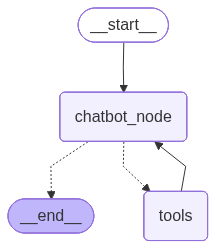

In [22]:
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))  # type: ignore

In [23]:
graph.invoke({"messages":{"role":"user","content":"What is the price of AAPL? How much it will cost to buy 20 stocks of AMZN?"}})

{'messages': [HumanMessage(content='What is the price of AAPL? How much it will cost to buy 20 stocks of AMZN?', additional_kwargs={}, response_metadata={}, id='e3fa0544-c64d-4537-99c6-97828beb9f12'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'z3tmqxn80', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': 'b1y8z4nh8', 'function': {'arguments': '{"symbol":"AMZN"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 282, 'total_tokens': 313, 'completion_time': 0.042354884, 'completion_tokens_details': None, 'prompt_time': 0.013892316, 'prompt_tokens_details': None, 'queue_time': 0.161247993, 'total_time': 0.0562472}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--118b2a96-1f96-43a9-927f-f5f8